In [24]:
import pandas as pd
import json

def load_meta_json(file_path, max_lines=100000):
    data = []
    with open(file_path, "r") as f:
        for i, line in enumerate(f):
            if i >= max_lines:
                break
            try:
                data.append(json.loads(line))
            except:
                continue
    return pd.DataFrame(data)

meta_df = load_meta_json("meta_Electronics.jsonl")

print(meta_df.columns.tolist())
print(meta_df.head())


['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author']
               main_category  \
0            All Electronics   
1            All Electronics   
2                  Computers   
3             AMAZON FASHION   
4  Cell Phones & Accessories   

                                               title  average_rating  \
0             FS-1051 FATSHARK TELEPORTER V3 HEADSET             3.5   
1                      Ce-H22B12-S1 4Kx2K Hdmi 4Port             5.0   
2  Digi-Tatoo Decal Skin Compatible With MacBook ...             4.5   
3  NotoCity Compatible with Vivoactive 4 band 22m...             4.5   
4             Motorola Droid X Essentials Combo Pack             3.8   

   rating_number                                           features  \
0              6                                                 []   
1              1        

In [3]:
import pandas as pd
import json
import re

# Function to clean and standardize text data
def clean_text(text):
    """Clean and standardize text data"""
    if pd.isna(text): return ""
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    return text

# Load and preprocess the JSONL file
def preprocess_titles(file_path, max_lines=100000):
    """Preprocess titles from the JSONL file"""
    titles = []
    with open(file_path, 'r') as fp:
        for i, line in enumerate(fp):
            if i >= max_lines:
                break
            try:
                data = json.loads(line.strip())
                title = data.get("title", "")  # Extract the title
                cleaned_title = clean_text(title)  # Clean the title text
                titles.append(cleaned_title)
            except json.JSONDecodeError:
                # Handle any decoding errors gracefully
                print("Error decoding JSON, skipping line")
                continue
    return titles

# Example usage
file_path = "meta_Electronics.jsonl"  # Adjust to your file path
titles = preprocess_titles(file_path)

# Convert the list of titles into a DataFrame for further processing
df_titles = pd.DataFrame(titles, columns=["cleaned_title"])

# Display the first few rows to ensure preprocessing is correct
print(df_titles.head())


                                       cleaned_title
0              fs1051 fatshark teleporter v3 headset
1                        ceh22b12s1 4kx2k hdmi 4port
2  digitatoo decal skin compatible with macbook p...
3  notocity compatible with vivoactive 4 band 22m...
4             motorola droid x essentials combo pack


In [2]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

titles = df_titles['cleaned_title'].tolist()

vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)  
X = vectorizer.fit_transform(titles)

n_clusters = 5  
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=100)
kmeans.fit(X)

silhouette_avg = silhouette_score(X, kmeans.labels_)
print(f"Silhouette Score for KMeans with {n_clusters} clusters: {silhouette_avg}")

df_titles['cluster'] = kmeans.labels_

for cluster_id in range(n_clusters):
    print(f"Cluster {cluster_id}:")
    cluster_titles = df_titles[df_titles['cluster'] == cluster_id]['cleaned_title']
    print(cluster_titles.head())  
    print("\n" + "-"*50 + "\n")


KeyboardInterrupt: 

In [4]:
from sentence_transformers import SentenceTransformer


In [6]:
import pandas as pd
import json
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sentence_transformers import SentenceTransformer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import nltk

# Download NLTK resources (first-time only)
nltk.download('wordnet')
nltk.download('stopwords')

# Enhanced text cleaning with lemmatization
class TextPreprocessor:
    def __init__(self):
        self.lemmatizer = WordNetLemmatizer()
        self.stop_words = set(stopwords.words('english'))
        
    def clean_text(self, text):
        """Enhanced text cleaning with smart punctuation handling"""
        if pd.isna(text):
            return ""
            
        text = str(text).lower()
        
        # Preserve important symbols and versions
        text = re.sub(r'(?<=\w)\.(?=\w)', '_dot_', text)  # model.number
        text = re.sub(r'(^|\s)v(\d+)\b', r'\1version_\2', text)  # v2 → version_2
        text = re.sub(r'[^\w\s\+]', ' ', text)  # Remove most punctuation
        
        # Lemmatization and stopword removal
        words = text.split()
        words = [self.lemmatizer.lemmatize(w) for w in words 
                if w not in self.stop_words and len(w) > 2]
                
        return ' '.join(words)

# Data loading with chunking for large files
def load_and_preprocess(filepath, sample_size=50000):
    """Load JSONL data with efficient chunking"""
    data = []
    preprocessor = TextPreprocessor()
    
    with open(filepath, 'r') as f:
        for i, line in enumerate(f):
            if i >= sample_size:
                break
            try:
                item = json.loads(line)
                title = item.get('title', '')
                cleaned = preprocessor.clean_text(title)
                if len(cleaned.split()) >= 2:  # Filter very short titles
                    data.append(cleaned)
            except json.JSONDecodeError:
                continue
    
    return pd.DataFrame(data, columns=['cleaned_title'])

# Feature engineering with both TF-IDF and SBERT options
def create_features(df, method='tfidf'):
    """Generate features using specified method"""
    if method == 'tfidf':
        vectorizer = TfidfVectorizer(
            max_features=10000,
            ngram_range=(1, 3),
            min_df=5,
            max_df=0.8,
            stop_words='english'
        )
        features = vectorizer.fit_transform(df['cleaned_title'])
        return features, vectorizer
    
    elif method == 'sbert':
        model = SentenceTransformer('all-MiniLM-L6-v2')
        embeddings = model.encode(df['cleaned_title'].tolist())
        return embeddings, None

# Optimal clustering with auto-K selection
def cluster_products(features, max_k=10):
    """Smart clustering with automatic K selection"""
    best_k = 2
    best_score = -1
    best_model = None
    
    for k in range(2, min(max_k, len(features)//10 + 2)):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
        labels = kmeans.fit_predict(features)
        
        if len(set(labels)) > 1:
            score = silhouette_score(features, labels)
            if score > best_score:
                best_score = score
                best_k = k
                best_model = kmeans
    
    print(f"Optimal clusters: {best_k} (silhouette: {best_score:.3f})")
    return best_model

# Main processing pipeline
def full_processing_pipeline(filepath):
    """End-to-end processing pipeline"""
    # 1. Load and clean data
    print("Loading and preprocessing data...")
    df = load_and_preprocess(filepath)
    print(f"Processed {len(df)} product titles")
    
    # 2. Feature engineering
    print("\nCreating features...")
    features, vectorizer = create_features(df, method='sbert')  # Try 'tfidf' or 'sbert'
    
    # 3. Clustering
    print("\nClustering products...")
    model = cluster_products(features)
    df['cluster'] = model.labels_
    
    # 4. Analysis
    print("\nCluster distribution:")
    print(df['cluster'].value_counts())
    
    return df, model, vectorizer

# Execute the pipeline
if __name__ == "__main__":
    file_path = "meta_Electronics.jsonl"
    df_result, model, vectorizer = full_processing_pipeline(file_path)
    
    # Example: Show top terms per cluster (for TF-IDF)
    if vectorizer:
        print("\nTop terms per cluster:")
        order_centroids = model.cluster_centers_.argsort()[:, ::-1]
        terms = vectorizer.get_feature_names_out()
        for i in range(model.n_clusters):
            print(f"\nCluster {i}:")
            print(", ".join(terms[ind] for ind in order_centroids[i, :10]))

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\7azmi\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\7azmi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Loading and preprocessing data...
Processed 49934 product titles

Creating features...

Clustering products...
Optimal clusters: 5 (silhouette: 0.054)

Cluster distribution:
cluster
3    12619
1    11715
0     9759
4     8400
2     7441
Name: count, dtype: int64


Cluster Distribution:
cluster
3    12619
1    11715
0     9759
4     8400
2     7441
Name: count, dtype: int64


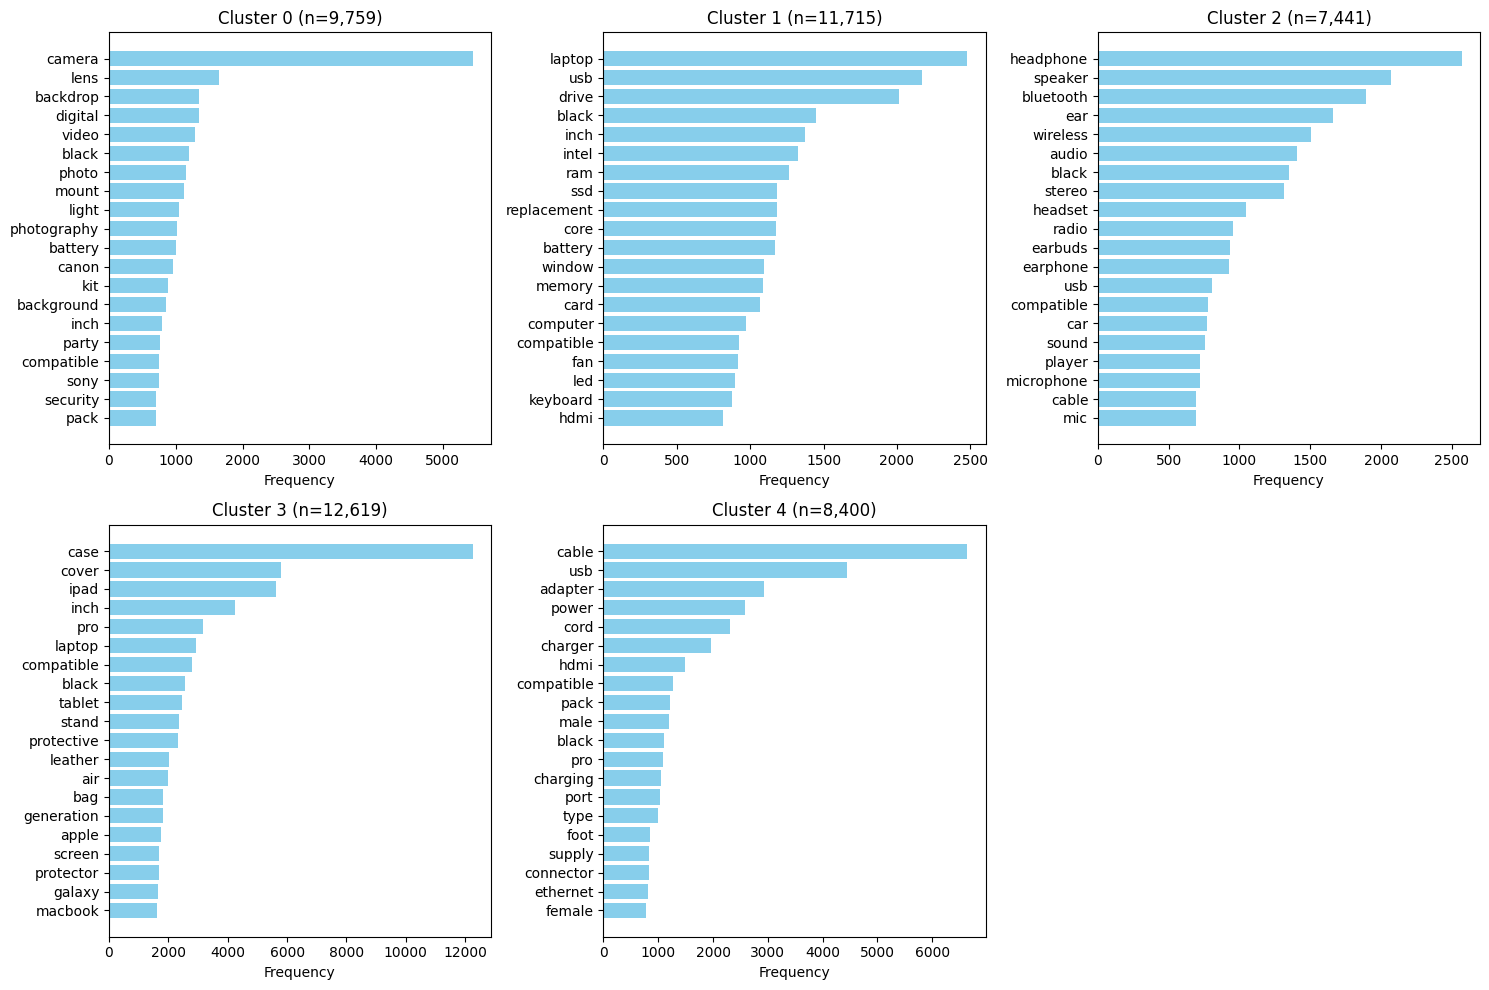


Top Product Titles per Cluster:

--- CLUSTER 0 ---
1. polaroid one instant camera discontinued manufacturer
2. amazon basic ion battery canon camera
3. trlyc white photography backdrop 8_dot_5 white backdrop photoshoot backdrop clip backdrop party curtain photographic studio photo background
4. mocsicka neon birthday backdrop laser glow dark party decoration photo backdrop let glow bday cake table photography background 7x5ft
5. nikon dslr camera body 1624 nikon 200 500mm lens 120gb xqd card el18c battery case corel photo software led light hdmi cable international model renewed
6. knowink remanufactured ink cartridge replacement canon 240xl 241xl 240 241 canon pixma ts5120 mg3620 mg3520 mg2120 mx452 mx472 mx512 mx532 black tri color pack
7. canon zoom lens 172187 47900
8. gobe 58mm circular polarizing cpl lens filter kit 2peak
9. deep whale mini poolside umbrella shade phone drink
10. gopro karma grip hero5 black gopro official accessory

--- CLUSTER 1 ---
1. click 4gb 8gb 16gb 32gb 

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

def analyze_clusters(df, n_samples=10, top_words=20):
    # 1. Basic Stats
    cluster_stats = df['cluster'].value_counts()
    print("Cluster Distribution:")
    print(cluster_stats)
    
    # 2. Top Terms Analysis
    plt.figure(figsize=(15, 10))
    for cluster_id in sorted(df['cluster'].unique()):
        # Get all words in the cluster
        words = ' '.join(df[df['cluster'] == cluster_id]['cleaned_title']).split()
        word_counts = Counter(words)
        
        # Get top words - CORRECTED THIS LINE
        top_words_list = word_counts.most_common(top_words)  # Fixed method name
        terms, counts = zip(*top_words_list)
        
        # Create bar plot
        plt.subplot(2, 3, cluster_id+1)
        plt.barh(range(len(terms)), counts, color='skyblue')
        plt.yticks(range(len(terms)), terms)
        plt.title(f'Cluster {cluster_id} (n={cluster_stats[cluster_id]:,})')
        plt.xlabel('Frequency')
        plt.gca().invert_yaxis()
    
    plt.tight_layout()
    plt.show()
    
    # 3. Representative Samples
    print("\nTop Product Titles per Cluster:")
    for cluster_id in sorted(df['cluster'].unique()):
        print(f"\n--- CLUSTER {cluster_id} ---")
        samples = df[df['cluster'] == cluster_id]['cleaned_title'].sample(
            min(n_samples, cluster_stats[cluster_id]),  # Handle small clusters
            random_state=42).tolist()
        for i, title in enumerate(samples, 1):
            print(f"{i}. {title}")

# Run analysis
analyze_clusters(df_result)

In [8]:
import joblib

# Save the model and vectorizer
def save_model(model, vectorizer, model_filename='clustering_done_model.joblib', vectorizer_filename='clustering_done_vectorizer.joblib'):
    """Save the model and vectorizer to files"""
    joblib.dump(model, model_filename)  # Save the KMeans model
    joblib.dump(vectorizer, vectorizer_filename)  # Save the vectorizer

# Call this function after you have trained your model
save_model(model, vectorizer, model_filename='clustering_done_model.joblib', vectorizer_filename='clustering_done_vectorizer.joblib')


In [12]:
import joblib
vectorizer = joblib.load('clustering_done_vectorizer.joblib')
print(vectorizer)  # Check if it prints the expected vectorizer object


None
